<div style="border: 5px solid #003366; border-radius: 8px; padding: 20px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 2.2
### **Date:** 03/23/2026

---

We will load, inspect, and visualize the data using Pandas and Matplotlib, working through three core research questions about global happiness patterns, economic factors, and the contributors that drive well-being across 143 countries.

---

**Reference:**

Jainaru. (2024). *World Happiness Report 2024* [Data set]. Kaggle. https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated

</div>

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from IPython.display import display, HTML

display(HTML('''
<style>
    div.output_subarea { page-break-inside: avoid; }
    div.jp-MarkdownOutput { page-break-inside: avoid; }
    div.cell { page-break-inside: avoid; }
</style>
'''))

# Suppress warnings
warnings.filterwarnings('ignore')

# Suppress scientific notation and format numbers with commas
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', 20)

# Global color palette: colorblind-safe
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#DAA520', '#C71585',
           '#6A5ACD', '#2E8B57', '#8B0000', '#556B2F', '#9932CC']
BLUE = '#4169E1'
PURPLE = '#4B0082'
GREEN = '#228B22'

# Set global plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset
df = pd.read_csv('WHR_2024.csv', encoding='latin-1')

print('✅ Libraries loaded and dataset ready!')
print(f'📦 Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns')
print(f'📋 Columns: {list(df.columns)}')

✅ Libraries loaded and dataset ready!
📦 Shape: 143 rows × 12 columns
📋 Columns: ['Country name', 'Regional indicator', 'Ladder score', 'upperwhisker', 'lowerwhisker', 'Log GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Dystopia + residual']


### Data Summary and Introduction

The World Happiness Report is an annual publication produced by the Sustainable Development Solutions Network that ranks countries based on how happy their citizens perceive themselves to be. The 2024 edition covers **143 countries** and is built around responses to the Cantril Ladder question, which asks respondents to imagine a ladder where 0 represents the worst possible life and 10 represents the best possible life. The resulting **Ladder score** serves as each country's happiness score and is the central variable in this analysis.

Beyond the happiness score itself, the dataset includes six contributing factors that help explain why some countries score higher than others: GDP per capita (log-adjusted), social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption. Each of these factors represents a national average drawn from survey responses and is used to decompose the overall happiness score into meaningful components.

---

**Research Questions:**

1. Which regions of the world report the highest and lowest happiness scores in 2024, and how do they compare across all regions?
2. Is there a measurable relationship between a country's economic output (Log GDP per capita) and its happiness score?
3. Which contributing factors have the strongest correlation with overall happiness, and does that ranking align with intuition?

In [2]:
# Summary statistics for key columns
print('📊 Summary Statistics:')
display(df[['Ladder score', 'Log GDP per capita', 'Social support',
            'Healthy life expectancy', 'Freedom to make life choices',
            'Generosity', 'Perceptions of corruption']].describe())

# Check for missing values
print('\n🔍 Missing Values per Column:')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('✅ No missing values found!')
else:
    display(missing)

📊 Summary Statistics:


,Ladder score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,143.0000,140.0000,140.0000,140.0000,140.0000,140.0000,140.0000
mean,5.5276,1.3788,1.1343,0.5209,0.6206,0.1463,0.1541
std,1.1707,0.4251,0.3333,0.1649,0.1625,0.0734,0.1262
min,1.7210,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,4.7260,1.0777,0.9218,0.3980,0.5275,0.0910,0.0688
50%,5.7850,1.4315,1.2375,0.5495,0.6410,0.1365,0.1205
75%,6.4160,1.7415,1.3832,0.6485,0.7360,0.1925,0.1938
max,7.7410,2.1410,1.6170,0.8570,0.8630,0.4010,0.5750



🔍 Missing Values per Column:


Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The World Happiness Report 2024 covers 143 countries across 10 regions, with each row representing a single country's happiness score and contributing factor values. The average global Ladder score is 5.53 out of 10, ranging from 1.72 to 7.74. Three countries are missing values across the six contributing factor columns, representing less than 3% of the dataset and will not materially affect the analysis.

</div>

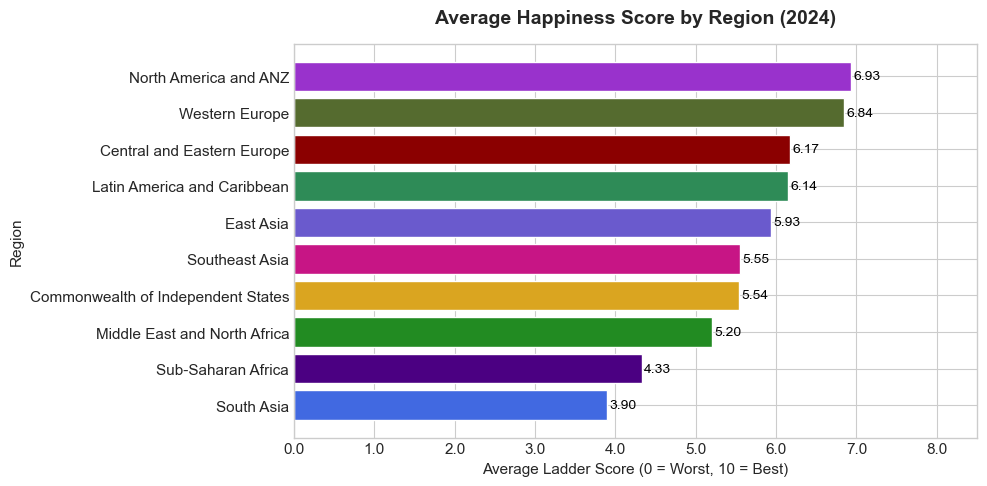


📊 Regional Happiness Summary:
Regional indicator
North America and ANZ                6.9277
Western Europe                       6.8416
Central and Eastern Europe           6.1709
Latin America and Caribbean          6.1434
East Asia                            5.9343
Southeast Asia                       5.5519
Commonwealth of Independent States   5.5385
Middle East and North Africa         5.1999
Sub-Saharan Africa                   4.3297
South Asia                           3.8957


In [3]:
# Compute average Ladder score per region and sort from highest to lowest
regional_avg = (
    df.groupby('Regional indicator')['Ladder score']
    .mean()
    .sort_values(ascending=True)
)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    regional_avg.index,
    regional_avg.values,
    color=PALETTE[:len(regional_avg)],
    edgecolor='white'
)

# Add value labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        fontsize=10,
        color='black'
    )

# Formatting
ax.set_title(
    'Average Happiness Score by Region (2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Average Ladder Score (0 = Worst, 10 = Best)')
ax.set_ylabel('Region')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.set_xlim(0, 8.5)
plt.tight_layout()
plt.show()

print(f'\n📊 Regional Happiness Summary:')
print(regional_avg.sort_values(ascending=False).to_string())

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

North America and ANZ (6.93) and Western Europe (6.84) lead all regions, while Sub-Saharan Africa (4.33) and South Asia (3.90) sit significantly below the global average of 5.53. The nearly three-point gap between the top and bottom regions suggests that geographic and systemic factors are strongly associated with perceived life satisfaction, though establishing causation would require deeper analysis.

</div>

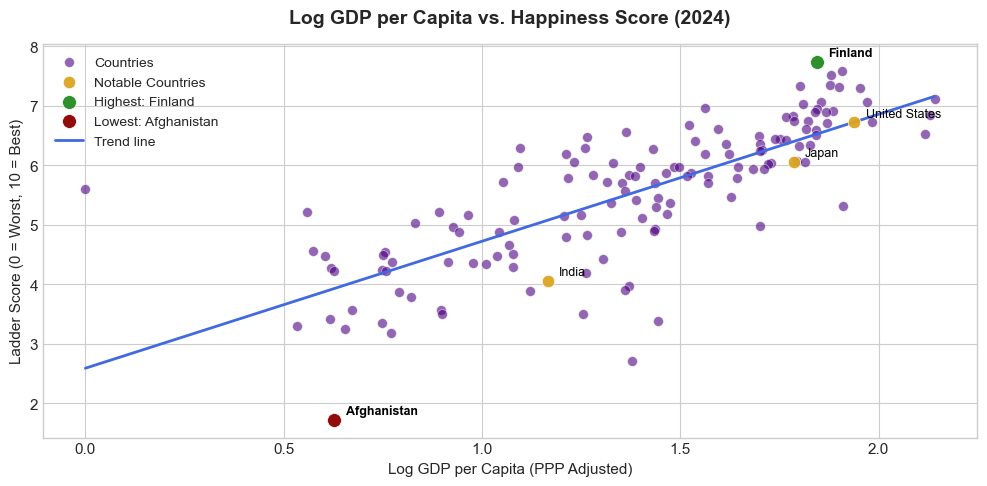


📈 Pearson Correlation Coefficient (GDP vs Happiness): 0.77
📌 Highest happiness: Finland | Lowest happiness: Afghanistan
📌 Trend line slope: 2.14 — for every 1-unit increase in Log GDP, happiness increases by 2.14 points


In [4]:
# Drop missing values
df_q2 = df[['Country name', 'Ladder score', 'Log GDP per capita']].dropna()

# Calculate Pearson correlation coefficient
corr = df_q2['Log GDP per capita'].corr(df_q2['Ladder score'])

# Fit a trend line
m, b = np.polyfit(df_q2['Log GDP per capita'], df_q2['Ladder score'], 1)
x_line = np.linspace(
    df_q2['Log GDP per capita'].min(),
    df_q2['Log GDP per capita'].max(),
    100)

# Define country groups
highlight = ['Finland', 'Afghanistan', 'United States', 'India', 'Japan']
top_country = df_q2.loc[df_q2['Ladder score'].idxmax(), 'Country name']
bot_country = df_q2.loc[df_q2['Ladder score'].idxmin(), 'Country name']
special = highlight + [top_country, bot_country]

df_base = df_q2[~df_q2['Country name'].isin(special)]
df_highlight = df_q2[df_q2['Country name'].isin(
    highlight) & ~df_q2['Country name'].isin([top_country, bot_country])]
df_top = df_q2[df_q2['Country name'] == top_country]
df_bot = df_q2[df_q2['Country name'] == bot_country]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Base scatter
ax.scatter(
    df_base['Log GDP per capita'],
    df_base['Ladder score'],
    color=PURPLE,
    alpha=0.6,
    s=50,
    edgecolors='white',
    linewidths=0.5,
    label='Countries'
)

# Highlighted scatter
ax.scatter(
    df_highlight['Log GDP per capita'],
    df_highlight['Ladder score'],
    color='#DAA520',
    alpha=0.95,
    s=80,
    edgecolors='white',
    linewidths=0.5,
    zorder=5,
    label='Notable Countries'
)

# Highest happiness country
ax.scatter(
    df_top['Log GDP per capita'],
    df_top['Ladder score'],
    color=GREEN,
    alpha=0.95,
    s=100,
    edgecolors='white',
    linewidths=0.5,
    zorder=6,
    label=f'Highest: {top_country}'
)

# Lowest happiness country
ax.scatter(
    df_bot['Log GDP per capita'],
    df_bot['Ladder score'],
    color='#8B0000',
    alpha=0.95,
    s=100,
    edgecolors='white',
    linewidths=0.5,
    zorder=6,
    label=f'Lowest: {bot_country}'
)

# Trend line
ax.plot(
    x_line,
    m * x_line + b,
    color='#4169E1',
    linewidth=2,
    label='Trend line')

# Annotate highlighted countries
for _, row in df_highlight.iterrows():
    ax.annotate(
        row['Country name'],
        xy=(row['Log GDP per capita'], row['Ladder score']),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=9,
        color='black'
    )

# Annotate highest and lowest
for df_ann in [df_top, df_bot]:
    for _, row in df_ann.iterrows():
        ax.annotate(
            row['Country name'],
            xy=(row['Log GDP per capita'], row['Ladder score']),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Formatting
ax.set_title(
    'Log GDP per Capita vs. Happiness Score (2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Log GDP per Capita (PPP Adjusted)')
ax.set_ylabel('Ladder Score (0 = Worst, 10 = Best)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'\n📈 Pearson Correlation Coefficient (GDP vs Happiness): {corr:.2f}')
print(f'📌 Highest happiness: {top_country} | Lowest happiness: {bot_country}')
print(
    f'📌 Trend line slope: {m:.2f} — for every 1-unit increase in Log GDP, happiness increases by {m:.2f} points')

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

A Pearson correlation of **r = 0.77** confirms a strong positive relationship between economic output and happiness, with the trend line slope of 2.14 indicating that each one-unit increase in Log GDP per capita is associated with a 2.14-point rise in the Ladder score. Finland ranked highest at 7.74 and Afghanistan lowest at 1.72. The scatter around the trend line suggests GDP alone does not fully explain happiness differences, pointing to the influence of additional factors.

</div>

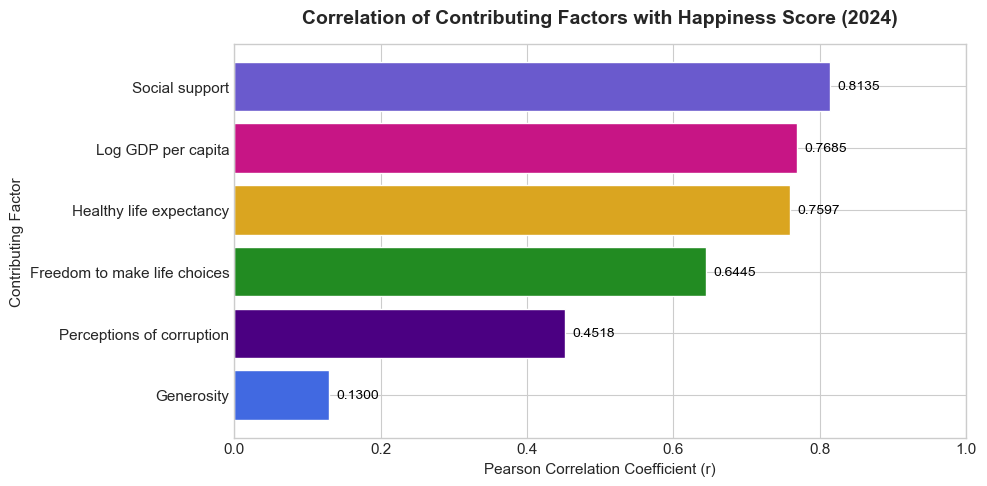


📊 Correlation with Ladder Score:
Social support                 0.8135
Log GDP per capita             0.7685
Healthy life expectancy        0.7597
Freedom to make life choices   0.6445
Perceptions of corruption      0.4518
Generosity                     0.1300


In [5]:
# Define contributing factors
factors = [
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Calculate Pearson correlation of each factor with Ladder score
correlations = (
    df[factors + ['Ladder score']]
    .dropna()
    .corr()['Ladder score']
    .drop('Ladder score')
    .sort_values(ascending=True)
)

# Assign colors
bar_colors = PALETTE[:len(correlations)]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    correlations.index,
    correlations.values,
    color=bar_colors,
    edgecolor='white'
)

# Add values
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# Formatting
ax.set_title(
    'Correlation of Contributing Factors with Happiness Score (2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Pearson Correlation Coefficient (r)')
ax.set_ylabel('Contributing Factor')
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()

print('\n📊 Correlation with Ladder Score:')
print(correlations.sort_values(ascending=False).to_string())

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

Social support carries the strongest correlation with happiness at **r = 0.81**, narrowly ahead of Log GDP per capita (r = 0.77) and healthy life expectancy (r = 0.76), while generosity trails the field at r = 0.13. This suggests that feeling connected to others is at least as important to perceived happiness as economic output. All correlations are positive, though these relationships indicate association rather than causation.

</div>

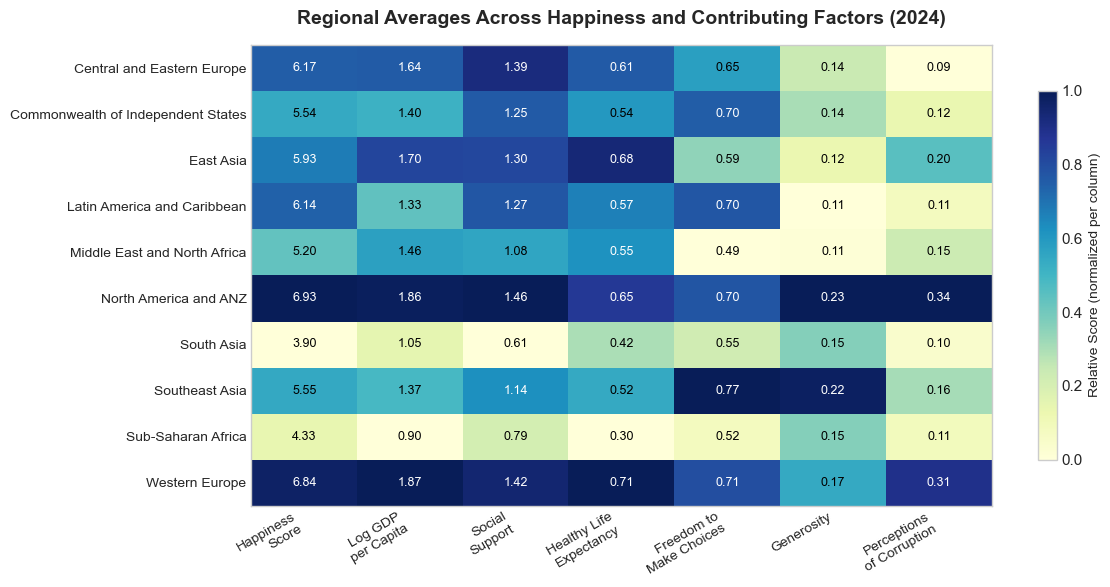

In [6]:
# Define contributing factors
factors = [
    'Ladder score',
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Compute regional averages for all factors
regional_heatmap = (
    df.groupby('Regional indicator')[factors]
    .mean()
    .round(4)
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize each column independently for color scaling
normalized = (regional_heatmap - regional_heatmap.min()) / \
    (regional_heatmap.max() - regional_heatmap.min())

im = ax.imshow(normalized.values, cmap='YlGnBu', aspect='auto')

# Remove gridlines
ax.grid(False)

# Set tick labels
ax.set_xticks(range(len(factors)))
ax.set_xticklabels(
    ['Happiness\nScore', 'Log GDP\nper Capita', 'Social\nSupport',
     'Healthy Life\nExpectancy', 'Freedom to\nMake Choices',
     'Generosity', 'Perceptions\nof Corruption'],
    fontsize=10,
    rotation=30,
    ha='right'
)
ax.set_yticks(range(len(regional_heatmap.index)))
ax.set_yticklabels(regional_heatmap.index, fontsize=10)

# Remove tick marks
ax.tick_params(which='both', length=0)

# Add values
for i in range(len(regional_heatmap.index)):
    for j in range(len(factors)):
        cell_val = normalized.values[i, j]
        text_color = 'white' if cell_val > 0.6 else 'black'
        ax.text(
            j, i,
            f'{regional_heatmap.values[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=9,
            color=text_color
        )

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Relative Score (normalized per column)', fontsize=10)

# Formatting
ax.set_title(
    'Regional Averages Across Happiness and Contributing Factors (2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The heatmap ties Q2 and Q3 together by showing regional averages across all contributing factors simultaneously. North America and ANZ and Western Europe score consistently high across nearly every column, while South Asia and Sub-Saharan Africa show weaker scores across most factors. Notably, generosity does not follow the same pattern as the other factors, with some lower-happiness regions scoring comparably to wealthier ones, consistent with its low correlation of r = 0.13 found in Q3.

</div>

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary and Conclusion

This analysis explored three questions about global happiness using the World Happiness Report 2024 dataset covering 143 countries across 10 regions.

---

**Q1 — Which regions report the highest and lowest happiness scores in 2024?**

The regional bar chart showed a clear and consistent hierarchy. North America and ANZ and Western Europe lead the world with average Ladder scores of 6.93 and 6.84 respectively, while South Asia (3.90) and Sub-Saharan Africa (4.33) sit significantly below all other regions. The gap between the happiest and least happy regions spans roughly three full points on a ten-point scale, indicating that where a person lives is strongly associated with how they rate their own life satisfaction.

---

**Q2 — Is there a measurable relationship between GDP per capita and happiness?**

The scatter plot and a Pearson correlation coefficient of **r = 0.77** confirmed a strong positive relationship between economic output and happiness. The trend line slope of 2.14 suggests that each one-unit increase in Log GDP per capita is associated with a 2.14-point increase in the Ladder score on average. Finland ranked highest at 7.74 and Afghanistan lowest at 1.72. That said, the scatter around the trend line makes clear that GDP alone does not determine happiness... several countries with similar economic output differ substantially in their scores, pointing to the influence of other factors.

---

**Q3 — Which contributing factors correlate most strongly with happiness?**

The horizontal bar chart revealed that social support carries the strongest correlation with happiness at **r = 0.81**, narrowly ahead of Log GDP per capita (r = 0.77) and healthy life expectancy (r = 0.76). Freedom to make life choices followed at r = 0.64, while perceptions of corruption (r = 0.45) and generosity (r = 0.13) trailed the field. The heatmap confirmed these patterns at the regional level, showing that the happiest regions tend to score consistently well across most contributing factors rather than excelling in just one area.

---

**Overall Conclusion**

The visualizations collectively suggest that happiness at the national level is shaped by a combination of economic, social, and institutional factors working together. No single variable fully explains the distribution of happiness scores across countries. While GDP per capita is a strong predictor, social support edges it out as the most correlated factor in this dataset, which suggests that the strength of human connection and community may matter at least as much as material wealth when it comes to perceived life satisfaction. These findings are supported directly by the data visualized here, though establishing causal relationships would require deeper analysis beyond the scope of this assignment.

</div>

<div style="border: 5px solid #228B22; border-radius: 8px; padding: 20px;">

# 📝 Reflection – Exercise 2.2 

## **Overall Reflection**
This assignment strengthened my ability to use Matplotlib not just as a plotting tool, but as a communication tool. Working with the World Happiness Report 2024 dataset allowed me to explore meaningful global patterns while practicing professional‑quality visualization techniques. The combination of bar charts, scatter plots, and correlation analysis helped me answer the research questions clearly and reinforced the importance of thoughtful labeling, color consistency, and readability. The process also highlighted how visualization choices can shape interpretation, especially when comparing regions or evaluating relationships between variables.

---

## **Straightforward Aspects**
- **Loading and preparing the dataset** was simple, especially since the CSV was clean and well‑structured.  
- **Creating basic Matplotlib figures** (bar charts, scatter plots, heatmaps) felt intuitive after reviewing the tutorials.  
- **Computing summary statistics and correlations** using Pandas was direct and aligned well with the research questions.  
- **Applying consistent color palettes and formatting** was manageable once the global style settings were established.  
- **Interpreting the visual outputs** came naturally because the patterns in the dataset were strong and easy to articulate.

---

## **Challenging Aspects**
- **Fine‑tuning plot aesthetics** (annotations, spacing, label rotation, DPI) required multiple iterations to achieve a polished, publication‑ready look.  
- **Managing overlapping annotations** in the scatter plot, especially for highlighted countries, took extra effort to position cleanly.  
- **Normalizing values for the heatmap** while still displaying the original numbers required careful handling to avoid confusion.  
- **Ensuring regional comparisons were fair** meant double‑checking groupings and averages to avoid misinterpretation.  
- **Balancing visual complexity with clarity** was challenging, especially when combining multiple factors into a single figure.

